# Unsupervised Learning in JAX

This notebook demonstrates an unsupervised learning workflow in JAX using k-means clustering on synthetic data.

The example shows how to build an iterative clustering algorithm using vectorized array operations and explicit update steps.

## Problem Setup

Unsupervised learning works with unlabeled data and tries to discover structure hidden in the feature space.

Here we generate three clusters of points, then ask k-means to recover the cluster assignments without using labels during training.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(42)
key, data_key, init_key = jax.random.split(key, 3)
cluster_centers = jnp.array([[-4.0, -2.0], [0.0, 4.0], [4.0, -1.0]])
points_per_cluster = 120
samples = []

for index, center in enumerate(cluster_centers):
    data_key, subkey = jax.random.split(data_key)
    samples.append(jax.random.normal(subkey, (points_per_cluster, 2)) * 0.8 + center)

X = jnp.concatenate(samples, axis=0)
X = X[jax.random.permutation(data_key, X.shape[0])]

## K-Means Algorithm

K-means alternates between assigning each point to its nearest center and updating each center to the mean of its assigned points.

Although simple, it is a classic unsupervised learning technique for discovering cluster structure in data.

In [2]:
def initialize_centroids(inputs, k, key):
    indices = jax.random.choice(key, inputs.shape[0], shape=(k,), replace=False)
    return inputs[indices]

def assign_clusters(inputs, centroids):
    distances = jnp.sum((inputs[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    return jnp.argmin(distances, axis=1)

def update_centroids(inputs, assignments, k):
    def centroid_for_cluster(cluster_index):
        mask = (assignments == cluster_index).astype(jnp.float32)[:, None]
        total = jnp.sum(mask * inputs, axis=0)
        count = jnp.sum(mask)
        return jnp.where(count > 0, total / count, inputs[0])

    return jax.vmap(centroid_for_cluster)(jnp.arange(k))

def kmeans(inputs, k=3, steps=20, key=jax.random.PRNGKey(0)):
    centroids = initialize_centroids(inputs, k, key)
    for _ in range(steps):
        assignments = assign_clusters(inputs, centroids)
        centroids = update_centroids(inputs, assignments, k)
    return centroids, assignments

centroids, assignments = kmeans(X, key=init_key)
centroids

Array([[ 4.0182743 , -0.8496659 ],
       [-4.073101  , -2.0259974 ],
       [-0.11422213,  4.0878744 ]], dtype=float32)

## Results and Interpretation

We visualize the final cluster assignments and centroid locations to see how well the algorithm recovered the latent structure.

In unsupervised learning, the output is not compared against labels during training, so interpretation happens through structure and visualization.

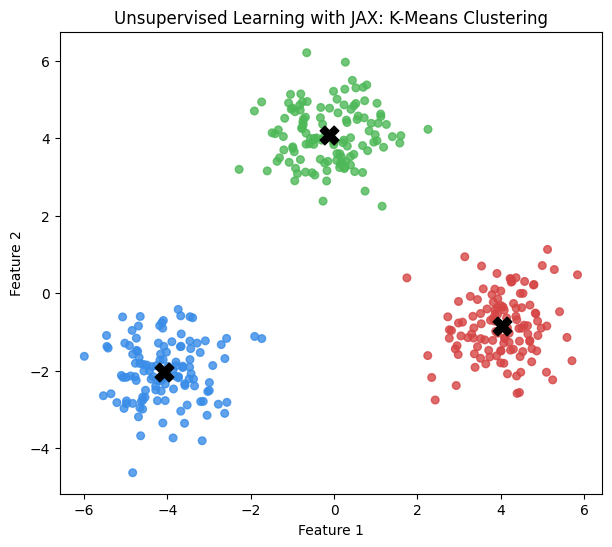

In [3]:
palette = jnp.array([[0.84, 0.27, 0.27], [0.22, 0.55, 0.91], [0.30, 0.72, 0.34]])
colors = palette[assignments]

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=colors, s=30, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=180, marker='X')
plt.title('Unsupervised Learning with JAX: K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()